# 04 — Revenue Trend Analysis

**Goal:** Understand *when* revenue is earned (seasonality, growth over time), *what* drives it (top products), and *where* it comes from (countries). This uses `cleaned_full_revenue.csv`, which — unlike the customer-level dataset — includes guest/unidentified checkouts, since we don't need a `CustomerID` for revenue totals to be valid.

In [1]:
import numpy as np 
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt 
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv(r"D:\ProProjects\data-analytics-projects\ecom\outputs\data\cleaned_full_revenue.csv", parse_dates=['invoicedate'])
print(f"Date range: {df['invoicedate'].min()} to {df['invoicedate'].max()}")
df.head()

Date range: 2010-12-01 08:26:00 to 2011-12-09 12:50:00


,invoiceno,stockcode,description,quantity,invoicedate,unitprice,customerid,country,iscancellation,totalprice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,False,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,False,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,False,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,False,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,False,20.34


## 1. Overall Monthly Revenue Trend

Note: December 2011 is a partial month because the dataset ends early in December. Any apparent decline in revenue for this month should therefore be interpreted with caution.

Number of distinct days with transactions in the final month (2011-12): 8


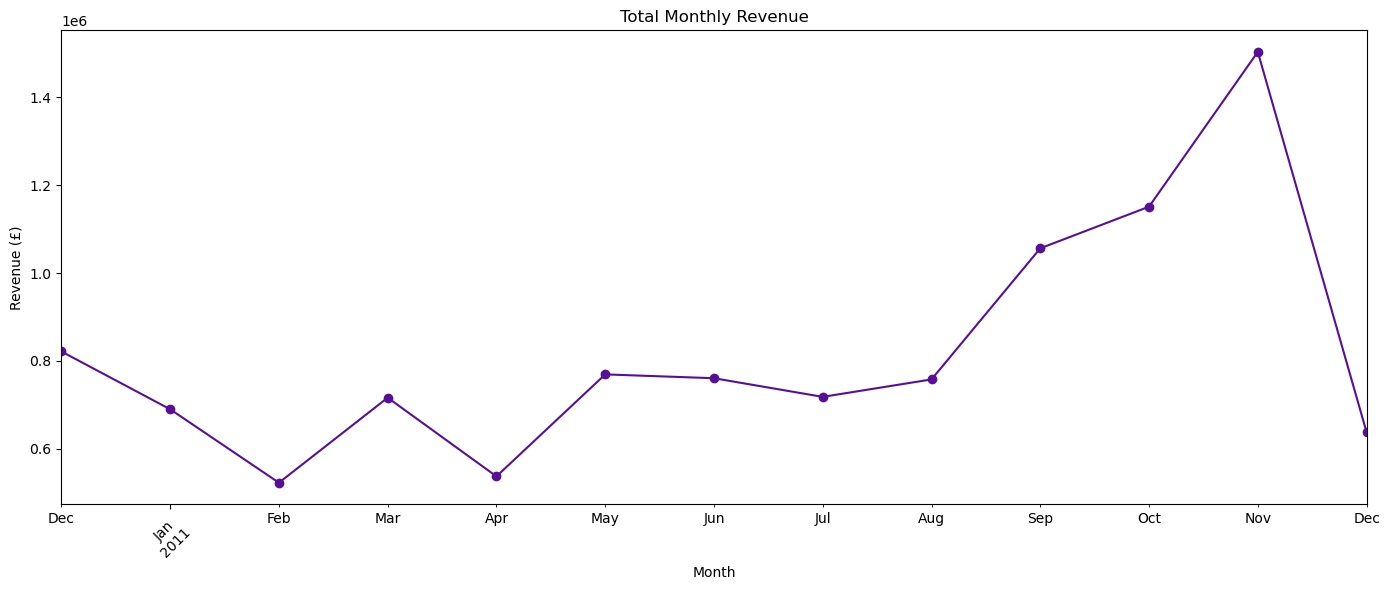

In [4]:
df['yearmonth'] = df['invoicedate'].dt.to_period('M')
monthly_revenue = df.groupby('yearmonth')['totalprice'].sum()

# Flag whether the last month is a partial month (fewer distinct days than a typical month)
last_month_days = df[df['yearmonth'] == monthly_revenue.index.max()]['invoicedate'].dt.day.nunique()
print(f"Number of distinct days with transactions in the final month ({monthly_revenue.index.max()}): {last_month_days}")

plt.figure(figsize=(14, 6))
monthly_revenue.plot(kind='line', marker='o', color='#571095')
plt.title('Total Monthly Revenue')
plt.ylabel('Revenue (£)')
plt.xlabel('Month')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('monthly_revenue_trend.png', bbox_inches='tight')
plt.show()

## 2. Year-over-Year Monthly Comparison

Compare each year's mo|nthly revenue on the same month-by-month timeline.This makes seasonal patterns easier to identify while highlighting year-over-year changes.

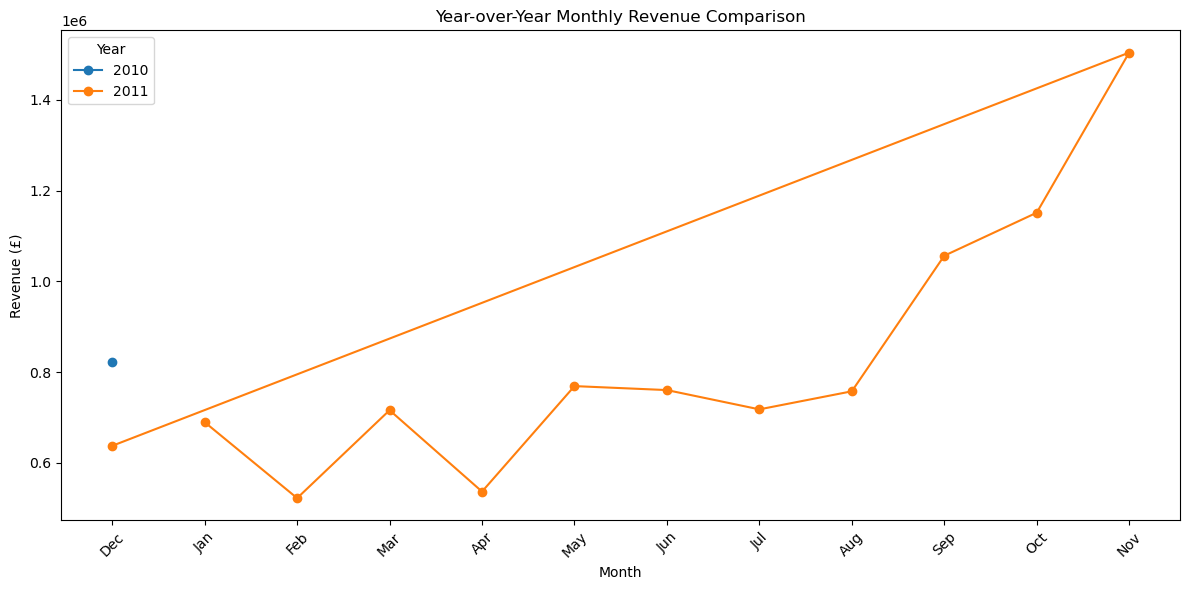

In [11]:
df['Year'] = df['invoicedate'].dt.year
df['Month'] = df['invoicedate'].dt.month
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

yoy = df.groupby(['Year', 'Month'])['totalprice'].sum().reset_index()
yoy['monthname'] = pd.Categorical(yoy['Month'].apply(lambda m: month_names[m-1]), categories=month_names, ordered=True)

plt.figure(figsize=(12, 6))
for year in sorted(yoy['Year'].unique()):
    subset = yoy[yoy['Year'] == year].sort_values('Month')
    plt.plot(subset['monthname'], subset['totalprice'], marker='o', label=str(year))

plt.title('Year-over-Year Monthly Revenue Comparison')
plt.ylabel('Revenue (£)')
plt.xlabel('Month')
plt.legend(title='Year')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('yoy_monthly_revenue.png', bbox_inches='tight')
plt.show()

## 3. Day-of-week and hour-of-day patterns

Might be useful for operational decisions — e.g. staffing customer support, timing email campaigns.

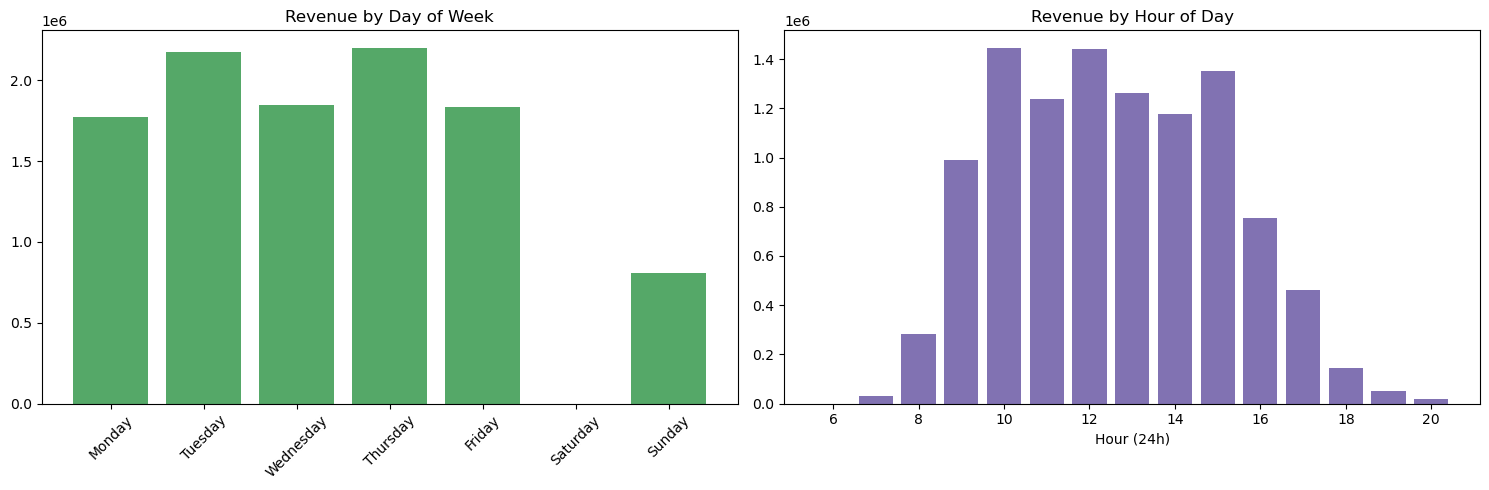

In [12]:
df['dayofweek'] = df['invoicedate'].dt.day_name()
df['hour'] = df['invoicedate'].dt.hour

dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow_revenue = df.groupby('dayofweek')['totalprice'].sum().reindex(dow_order)
hour_revenue = df.groupby('hour')['totalprice'].sum()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].bar(dow_revenue.index, dow_revenue.values, color='#55A868')
axes[0].set_title('Revenue by Day of Week')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(hour_revenue.index, hour_revenue.values, color='#8172B2')
axes[1].set_title('Revenue by Hour of Day')
axes[1].set_xlabel('Hour (24h)')

plt.tight_layout()
plt.savefig('dow_hour_revenue.png', bbox_inches='tight')
plt.show()

## 4. Top products by revenue and by quantity

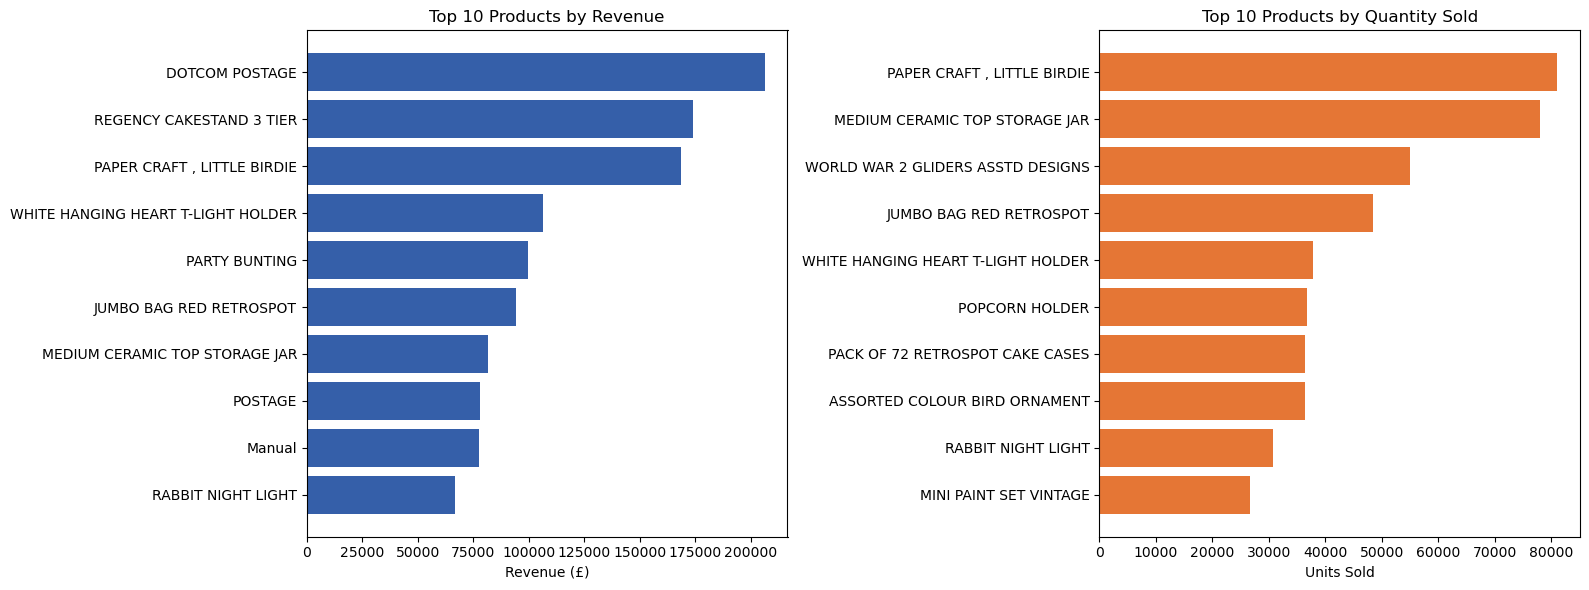

In [13]:
top_products_revenue = df.groupby('description')['totalprice'].sum().sort_values(ascending=False).head(10)
top_products_qty = df.groupby('description')['quantity'].sum().sort_values(ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(top_products_revenue.index[::-1], top_products_revenue.values[::-1], color='#355FA9')
axes[0].set_title('Top 10 Products by Revenue')
axes[0].set_xlabel('Revenue (£)')

axes[1].barh(top_products_qty.index[::-1], top_products_qty.values[::-1], color='#E57635')
axes[1].set_title('Top 10 Products by Quantity Sold')
axes[1].set_xlabel('Units Sold')

plt.tight_layout()
plt.savefig('top_products.png', bbox_inches='tight')
plt.show()

## 5. Revenue by country

United Kingdom accounts for 84.6% of total revenue.


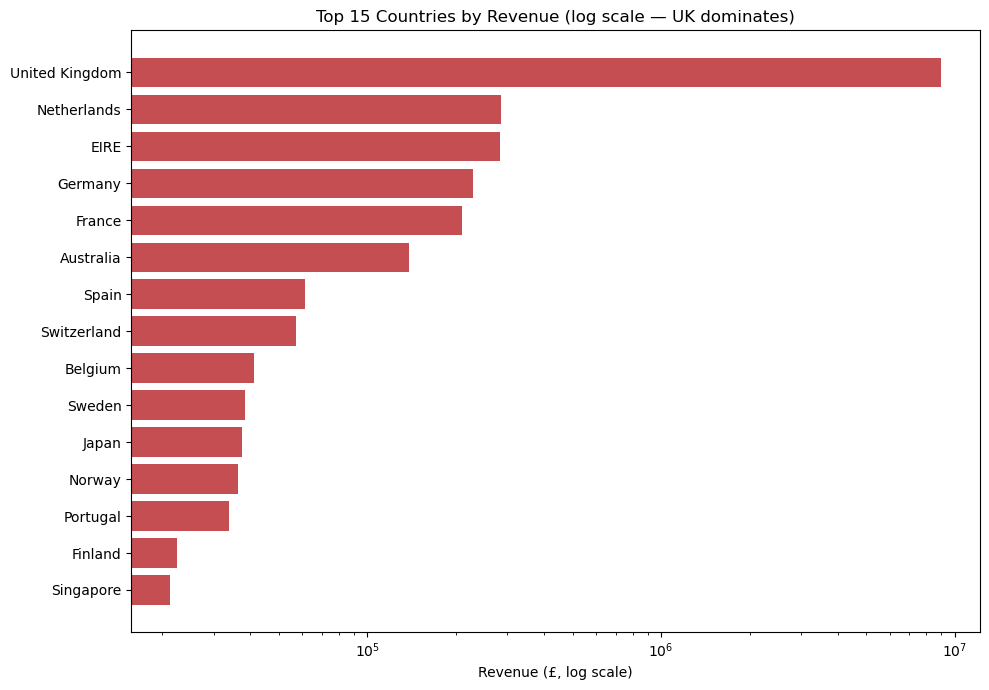

In [15]:
country_revenue = df.groupby('country')['totalprice'].sum().sort_values(ascending=False)
uk_share = country_revenue['United Kingdom'] / country_revenue.sum() * 100
print(f"United Kingdom accounts for {uk_share:.1f}% of total revenue.")

top_countries = country_revenue.head(15)

plt.figure(figsize=(10, 7))
plt.barh(top_countries.index[::-1], top_countries.values[::-1], color='#C44E52')
plt.xscale('log')
plt.xlabel('Revenue (£, log scale)')
plt.title('Top 15 Countries by Revenue (log scale — UK dominates)')
plt.tight_layout()
plt.savefig('revenue_by_country.png', bbox_inches='tight')
plt.show()

## 6. Top 10 Non - UK Countries by Revenue

Since the UK dwarfs everything else, a separate view of just the other markets is more actionable for an international-expansion conversation.

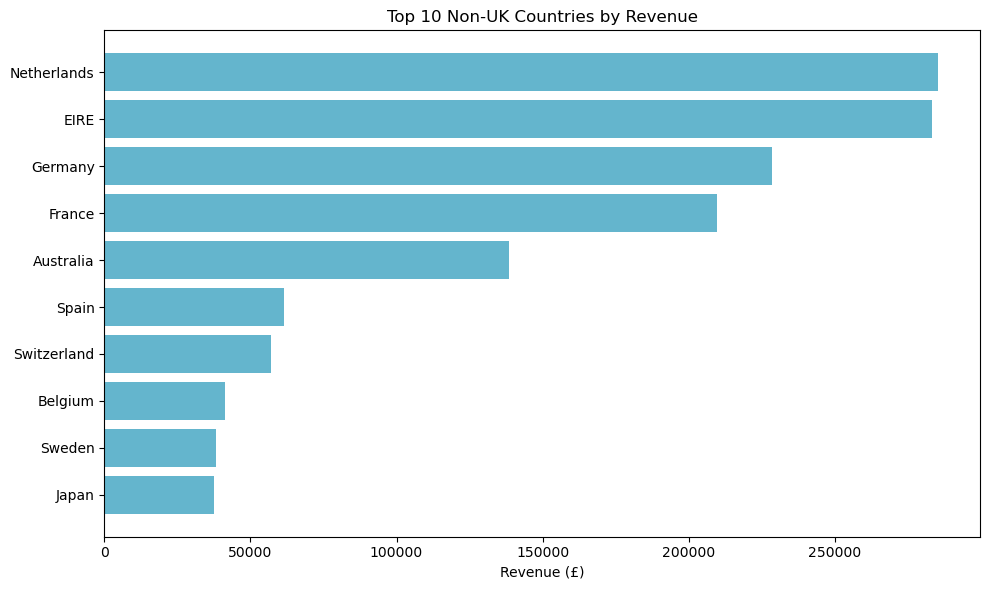

In [17]:
non_uk = country_revenue.drop('United Kingdom').head(10)

plt.figure(figsize=(10, 6))
plt.barh(non_uk.index[::-1], non_uk.values[::-1], color='#64B5CD')
plt.xlabel('Revenue (£)')
plt.title('Top 10 Non-UK Countries by Revenue')
plt.tight_layout()
plt.savefig('revenue_by_country_nonuk.png', bbox_inches='tight')
plt.show()

## 7. Order value distribution

count     19962.000000
mean        533.118465
std        1780.304163
min           0.380000
25%         151.710000
50%         303.300000
75%         493.450000
max      168469.600000
Name: totalprice, dtype: float64


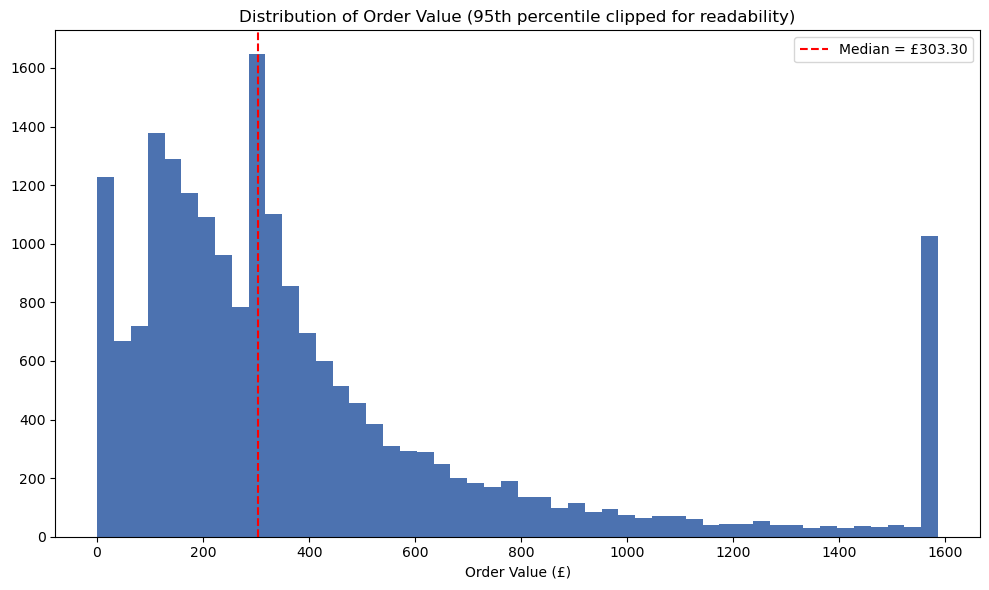

In [19]:
order_value = df.groupby('invoiceno')['totalprice'].sum()
print(order_value.describe())

plt.figure(figsize=(10, 6))
# to clip extreme outliers for visualization I am choosing 95%ile as safe limit
plt.hist(order_value.clip(upper=order_value.quantile(0.95)), bins=50, color='#4C72B0')
plt.axvline(order_value.median(), color='red', linestyle='--', label=f'Median = £{order_value.median():.2f}')
plt.title('Distribution of Order Value (95th percentile clipped for readability)')
plt.xlabel('Order Value (£)')
plt.legend()
plt.tight_layout()
plt.savefig('order_value_distribution.png', bbox_inches='tight')
plt.show()

# 8. Summary of this dataset

In [20]:
monthly_revenue.to_csv('monthly_revenue.csv')
country_revenue.to_csv('country_revenue.csv')
top_products_revenue.to_csv('top_products_revenue.csv')
print("Saved monthly_revenue.csv, country_revenue.csv, top_products_revenue.csv")

Saved monthly_revenue.csv, country_revenue.csv, top_products_revenue.csv


In [21]:
print("KEY INSIGHT")
print(f"1. UK accounts for {uk_share:.1f}% of revenue — international markets are a small but real growth opportunity, led by {non_uk.index[0]}.")
peak_month = monthly_revenue.idxmax()
print(f"2. Revenue peaks around {peak_month} — consistent with a Nov/Dec pre-Christmas ordering surge typical of gift/homeware retail.")
peak_day = dow_revenue.idxmax()
print(f"3. {peak_day} is the highest-revenue day of the week; there is no Saturday trading at all, reinforcing that this is a wholesale/B2B business, not consumer retail.")
print(f"4. Median order value is £{order_value.median():.2f}, but the distribution has a long right tail (mean £{order_value.mean():.2f}) driven by a small number of large wholesale orders.")

KEY INSIGHT
1. UK accounts for 84.6% of revenue — international markets are a small but real growth opportunity, led by Netherlands.
2. Revenue peaks around 2011-11 — consistent with a Nov/Dec pre-Christmas ordering surge typical of gift/homeware retail.
3. Thursday is the highest-revenue day of the week; there is no Saturday trading at all, reinforcing that this is a wholesale/B2B business, not consumer retail.
4. Median order value is £303.30, but the distribution has a long right tail (mean £533.12) driven by a small number of large wholesale orders.
